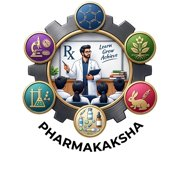

# BP801T · Unit IV — AI in Public Health and Real-World Data
**Pharmakaksha · Learn · Grow · Achieve**
*Ethical Considerations and Translational Applications of AI in Pharmacy · B.Pharm Semester VIII · PCI NEP 2020*

This notebook contains every example and demo from the Unit IV study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP801T%20Ethical%20Considerations%20and%20Translational%20Applications%20of%20AI%20in%20Pharmacy%20%28Theory%29/BP801T_Unit4_Public_Health_and_Real_World_Data.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP801T%20Ethical%20Considerations%20and%20Translational%20Applications%20of%20AI%20in%20Pharmacy%20%28Theory%29/BP801T_Unit4_Public_Health_and_Real_World_Data.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. The practice datasets sit next to this notebook. In Colab they are read from GitHub automatically.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. The first `import sklearn` takes a few seconds more. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All datasets are fictional teaching data. The models are for learning only. They are not clinical, regulatory or legal tools.

## 4.1 Real-world data (RWD)
**Real-world data** is health data collected during routine care and daily life, not in a controlled trial. Analysed well, it becomes **real-world evidence (RWE)**.

| Source | What it holds | Indian example |
|---|---|---|
| Electronic health records (EHR) | Diagnoses, labs, prescriptions | Hospital HIS; ABDM health records |
| Claims / insurance | Billed procedures and drugs | AB PM-JAY claims |
| Disease surveillance | Case counts by place and week | IDSP / IHIP |
| Pharmacovigilance | Suspected ADR reports | PvPI (Pharmacovigilance Programme of India) |
| Surveys and registries | Risk factors, prevalence | NFHS, ICMR-INDIAB, cancer registries |
| Devices and apps | Steps, glucose, BP | Wearables, CGM |

RWD is large and cheap, but it is **messy** (missing values, coding errors), **biased** (only people who reach care are recorded) and **delayed**. Every analysis in this unit uses regression, the workhorse of epidemiology.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/ajreddys/learn-pharmakaksha-site/main/content/BP801T%20Ethical%20Considerations%20and%20Translational%20Applications%20of%20AI%20in%20Pharmacy%20%28Theory%29/"

def load(name):
    """Read a practice CSV from this folder, or from GitHub (Colab)."""
    if os.path.exists(name):
        return pd.read_csv(name)
    return pd.read_csv(URL + name)

TEAL, GREEN, ORANGE, GREY = "#12303A", "#1F8A70", "#E07A2E", "#8A9BA3"
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
import statsmodels.api as sm
import statsmodels.formula.api as smf

## 4.2 Regression in epidemiology
| Outcome | Model | Result reported | Example in this unit |
|---|---|---|---|
| Count of cases | Poisson (or negative binomial) regression | Rate ratio | Dengue cases per week |
| Yes/no | Logistic regression | Odds ratio | Diabetes, vaccine hesitancy |
| Continuous / trend | Linear regression | Slope per year | Antibiotic resistance % |

## 4.3 Outbreak prediction — dengue
`dengue_weekly.csv` has seven years (2019–2025) of weekly dengue cases in a fictional district, with rainfall, temperature and humidity. Mosquitoes breed in rain-filled water, and cases follow rain by a few weeks. Which lag fits best?

In [ ]:
den = load("dengue_weekly.csv")
den["week_start"] = pd.to_datetime(den["week_start"])
for lag in range(0, 7):
    r = den["cases"].corr(den["rainfall_mm"].shift(lag))
    print(f"Rainfall {lag} weeks earlier: correlation with cases = {r:.2f}")

Rainfall **3 weeks earlier** predicts cases best. We fit a **Poisson regression** on 2019–2023 and forecast 2024–2025. Because the model uses rain from 3 weeks ago, it can warn 3 weeks ahead.

In [ ]:
den["rain_lag3"] = den["rainfall_mm"].shift(3)
den["covid_year"] = (den["year"] == 2020).astype(int)   # under-reporting in 2020
d = den.dropna().copy()
train = d[d["year"] <= 2023]
pois = smf.glm("cases ~ rain_lag3 + mean_temp_c + covid_year", data=train, family=sm.families.Poisson()).fit()
print(np.exp(pois.params).round(3).rename("rate ratio"))
print(f"\nEvery extra 10 mm of rain 3 weeks earlier multiplies expected cases by {np.exp(10 * pois.params['rain_lag3']):.2f}")

**Outbreak threshold (endemic channel).** A week is an **outbreak alert** when cases exceed the mean + 2 SD of the same time of year in earlier years (2019–2023, leaving out the COVID year 2020). For each week we pool that week and the two weeks on either side, which gives a steadier estimate. Small dry-season counts jump around by chance, so we also require at least **20 cases** before calling an outbreak.

In [ ]:
base = den[(den["year"] <= 2023) & (den["year"] != 2020)]
rows = []
for w in range(1, 54):
    nearby = [((w + k - 1) % 52) + 1 for k in range(-2, 3)]     # week w ± 2 weeks
    s = base.loc[base["week"].isin(nearby), "cases"]
    rows.append({"week": w, "threshold": max(s.mean() + 2 * s.std(), 20)})
channel = pd.DataFrame(rows).set_index("week")

test = d[d["year"] >= 2024].copy()
test["forecast"] = pois.predict(test)
test = test.merge(channel["threshold"], left_on="week", right_index=True)
test["alert_actual"] = test["cases"] > test["threshold"]
test["alert_forecast"] = test["forecast"] > test["threshold"]
print(f"Mean absolute error of weekly forecast: {np.mean(np.abs(test['cases'] - test['forecast'])):.1f} cases")
print("Outbreak weeks (actual):  ", test.loc[test["alert_actual"], "week_start"].dt.strftime("%Y-%m-%d").tolist())
print("Weeks the model warned of:", test.loc[test["alert_forecast"], "week_start"].dt.strftime("%Y-%m-%d").tolist())

In [ ]:
plt.figure(figsize=(10, 4.5))
plt.plot(test["week_start"], test["cases"], color=TEAL, label="Reported cases")
plt.plot(test["week_start"], test["forecast"], color=ORANGE, linestyle="--", label="Forecast (rain 3 weeks earlier)")
plt.plot(test["week_start"], test["threshold"], color=GREY, linewidth=1, label="Outbreak threshold")
plt.fill_between(test["week_start"], 0, test["cases"].max() * 1.05, where=test["alert_forecast"],
                 color=ORANGE, alpha=0.12, label="Model alert weeks")
plt.ylabel("Dengue cases per week"); plt.legend(fontsize=8, loc="upper left")
plt.title("Dengue early warning, 2024–2025 (very wet monsoon in 2024)")
plt.tight_layout(); plt.show()

The very wet 2024 monsoon produced a large outbreak (late August to early September). Because the model uses rain from three weeks earlier, it raised its first alert on 12 August, **two weeks before** cases crossed the threshold. That is time for fogging, larval control and hospital preparation. It also flagged the smaller August 2025 rise.

## 4.4 Population risk models — case: diabetes prevalence
`diabetes_survey.csv` is a fictional household survey of 3,000 adults (in the style of ICMR-INDIAB, which estimated diabetes in 11.4% of Indian adults in 2023).
**Step 1 — prevalence with a 95% confidence interval.**

In [ ]:
dm = load("diabetes_survey.csv")

def prevalence(s):
    p, n = s.mean(), len(s)
    se = np.sqrt(p * (1 - p) / n)
    return f"{p:.1%} (95% CI {p - 1.96 * se:.1%} to {p + 1.96 * se:.1%}), n = {n}"

print("Overall:", prevalence(dm["diabetes"]))
print("Urban:  ", prevalence(dm.loc[dm["urban"] == 1, "diabetes"]))
print("Rural:  ", prevalence(dm.loc[dm["urban"] == 0, "diabetes"]))

**Step 2 — which risk factors matter?** A logistic regression gives adjusted odds ratios.

In [ ]:
dm["female"] = (dm["sex"] == "F").astype(int)
dm["age10"] = dm["age"] / 10       # OR per 10 years
dm["bmi5"] = dm["bmi"] / 5         # OR per 5 BMI units
risk = smf.logit("diabetes ~ age10 + bmi5 + urban + family_history + physically_active + female", data=dm).fit(disp=0)
OR = pd.DataFrame({"OR": np.exp(risk.params), "CI_low": np.exp(risk.conf_int()[0]),
                   "CI_high": np.exp(risk.conf_int()[1])}).drop("Intercept").round(2)
print(OR)

**Step 3 — target screening.** The model gives each person a risk. Screening the top 20% by predicted risk finds a large share of all cases, at a fraction of the cost of screening everyone.

In [ ]:
from sklearn.metrics import roc_auc_score
dm["risk"] = risk.predict(dm)
print(f"AUC = {roc_auc_score(dm['diabetes'], dm['risk']):.2f}")
top = dm["risk"] >= dm["risk"].quantile(0.80)
print(f"Screening the top 20% finds {dm.loc[top, 'diabetes'].sum() / dm['diabetes'].sum():.0%} of all people with diabetes")

dm["decile"] = pd.qcut(dm["risk"], 10, labels=range(1, 11))
cal = dm.groupby("decile", observed=True)[["risk", "diabetes"]].mean() * 100
plt.bar(cal.index.astype(int) - 0.2, cal["risk"], width=0.4, color=TEAL, label="Predicted %")
plt.bar(cal.index.astype(int) + 0.2, cal["diabetes"], width=0.4, color=ORANGE, label="Observed %")
plt.xlabel("Risk decile (1 = lowest)"); plt.ylabel("Diabetes (%)"); plt.legend()
plt.title("Population risk model: predicted vs observed by decile")
plt.xticks(range(1, 11)); plt.tight_layout(); plt.show()

## 4.5 Vaccination forecasting
`vaccination_monthly.csv` has monthly measles–rubella (MR) doses given in a district from 2019 to 2025. Campaign months (April, October) are high, and peak monsoon months are lower. COVID-19 lockdown in April–June 2020 cut doses, followed by catch-up drives. We model trend + month and mark the disrupted months, then forecast 2026 to plan vaccine and syringe supplies.

In [ ]:
vac = load("vaccination_monthly.csv")
vac["date"] = pd.to_datetime(vac["month"])
vac["t"] = np.arange(len(vac))
vac["m"] = vac["date"].dt.month.astype(str)
vac["lockdown"] = vac["date"].between("2020-04-01", "2020-06-01").astype(int)
vac["catch_up"] = vac["date"].between("2020-08-01", "2020-11-01").astype(int)
vmodel = smf.ols("mr_doses ~ t + C(m) + lockdown + catch_up", data=vac).fit()
print(f"Trend: +{vmodel.params['t']:.1f} doses per month;  R² = {vmodel.rsquared:.2f}")

future = pd.DataFrame({"date": pd.date_range("2026-01-01", periods=12, freq="MS")})
future["t"] = np.arange(len(vac), len(vac) + 12)
future["m"] = future["date"].dt.month.astype(str)
future["lockdown"], future["catch_up"] = 0, 0
fc = vmodel.get_prediction(future).summary_frame(alpha=0.05)
future["forecast"], future["low"], future["high"] = fc["mean"], fc["obs_ci_lower"], fc["obs_ci_upper"]
print(f"Forecast for 2026: {future['forecast'].sum():,.0f} MR doses (monthly range {future['forecast'].min():,.0f}–{future['forecast'].max():,.0f})")

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(vac["date"], vac["mr_doses"], color=TEAL, label="Doses given")
plt.plot(future["date"], future["forecast"], color=ORANGE, label="2026 forecast")
plt.fill_between(future["date"], future["low"], future["high"], color=ORANGE, alpha=0.2, label="95% prediction interval")
plt.axvspan(pd.Timestamp("2020-04-01"), pd.Timestamp("2020-06-30"), color=GREY, alpha=0.2, label="COVID-19 lockdown")
plt.ylabel("MR doses per month"); plt.legend(fontsize=8, loc="upper left")
plt.title("Forecasting routine measles–rubella vaccination")
plt.tight_layout(); plt.show()

## 4.6 Case study: COVID-19 vaccine hesitancy
`vaccine_hesitancy.csv` is a fictional survey of 1,500 adults. *Hesitant* = delayed or refused a COVID-19 vaccine although it was available. Which factors are linked to hesitancy?

In [ ]:
vh = load("vaccine_hesitancy.csv")
print(f"Hesitant: {vh['hesitant'].mean():.0%}")
vh["age10"] = vh["age"] / 10
hes = smf.logit("hesitant ~ age10 + C(sex) + urban + C(education, Treatment('Secondary')) + trust_health_system"
                " + social_media_main_news + chronic_condition", data=vh).fit(disp=0)
ORh = pd.DataFrame({"OR": np.exp(hes.params), "CI_low": np.exp(hes.conf_int()[0]),
                    "CI_high": np.exp(hes.conf_int()[1]), "p": hes.pvalues}).drop("Intercept")
ORh.index = ORh.index.str.replace(r"C\(sex\)\[T\.M", "sex: male", regex=True)
ORh.index = ORh.index.str.replace(r"C\(education, Treatment\('Secondary'\)\)\[T\.", "education: ", regex=True).str.replace("]", "")
print(ORh.round(3))

In [ ]:
nice = {"social_media_main_news": "Social media is main news source", "education: None/Primary": "Education: none/primary",
        "education: Graduate+": "Education: graduate+", "age10": "Age (per 10 years)",
        "chronic_condition": "Has a chronic condition", "trust_health_system": "Trust in health system (per point)"}
plot_or = ORh.loc[list(nice)].rename(index=nice).sort_values("OR")
plt.figure(figsize=(8, 4))
plt.errorbar(plot_or["OR"], plot_or.index, xerr=[plot_or["OR"] - plot_or["CI_low"], plot_or["CI_high"] - plot_or["OR"]],
             fmt="o", color=TEAL, ecolor=GREY, capsize=4)
plt.axvline(1, color=ORANGE, linestyle="--")
plt.xscale("log"); plt.xticks([0.5, 0.75, 1, 1.5, 2, 3], ["0.5", "0.75", "1", "1.5", "2", "3"])
plt.minorticks_off(); plt.xlabel("Odds ratio for hesitancy (log scale; right of 1 = more hesitant)")
plt.title("What is linked to COVID-19 vaccine hesitancy?")
plt.tight_layout(); plt.show()

**Reading it:** people who get most of their news from **social media** have about 2.2 times the odds of hesitancy. Each extra point of **trust in the health system** (1–5 scale) cuts the odds by about 40% (OR 0.59). Older people, men and people with a **chronic condition** (OR 0.62) are less hesitant, and people with little schooling are more hesitant. Public-health teams can act on this: trusted local messengers (ASHA workers, pharmacists) and myth-busting on social media.

> Survey associations are **not** proof of cause, and survey data has its own biases (who answers, honest answers).

## 4.7 Case study: antibiotic resistance trends
`amr_trends.csv` gives the share of resistant isolates for four bug–drug pairs in a fictional surveillance network, 2016–2025. (For scale: WHO's GLASS 2025 report found about one in six lab-confirmed bacterial infections worldwide were resistant, and about one in three in the South-East Asia region.)

In [ ]:
amr = load("amr_trends.csv")
amr["pct"] = 100 * amr["resistant"] / amr["isolates_tested"]
amr["pair"] = amr["organism"] + " – " + amr["antibiotic"]
rows = []
for pair, s in amr.groupby("pair"):
    lm = smf.ols("pct ~ year", data=s).fit()
    rows.append({"pair": pair, "2025 %": round(s.loc[s.year == 2025, "pct"].iloc[0], 1),
                 "change per year (points)": round(lm.params["year"], 2),
                 "p-value": round(lm.pvalues["year"], 4),
                 "forecast 2027 %": round(lm.predict(pd.DataFrame({"year": [2027]}))[0], 1)})
trend = pd.DataFrame(rows).sort_values("change per year (points)", ascending=False)
print(trend.to_string(index=False))

In [ ]:
plt.figure(figsize=(9, 4.5))
for (pair, s), colour in zip(amr.groupby("pair"), [ORANGE, GREEN, TEAL, GREY]):
    plt.plot(s["year"], s["pct"], "o-", color=colour, label=pair)
plt.ylabel("Resistant isolates (%)"); plt.xticks(range(2016, 2026))
plt.legend(fontsize=8); plt.title("Antibiotic resistance trends, 2016–2025")
plt.tight_layout(); plt.show()

Carbapenem resistance in *K. pneumoniae* is rising fastest, by about 2.9 percentage points a year, and the trend reaches about 61% by 2027. That is a warning for antimicrobial stewardship: protect carbapenems, use culture-guided therapy, and track the trend every year.

## Quick check
A Poisson model gives a rate ratio of 1.18 for "rain_lag3 per 10 mm". In plain words, what does it mean? Decide, then run the cell.

In [ ]:
print("Each extra 10 mm of rain three weeks earlier is linked to about 18% more dengue cases this week.")

## Try it yourself (lab)
Write your code in the empty cells. Solutions are at the end of the notebook.

**1.** What was the total number of dengue cases in each year? Which year had the most?

**2.** Compute diabetes prevalence with 95% CI for people **with** and **without** a family history.

**3.** Refit the hesitancy model **without** `trust_health_system`. How does the odds ratio for social media change?

**4.** Using the trend table, in which year would *K. pneumoniae* carbapenem resistance reach 60% if the trend continued? (Hint: solve 60 = intercept + slope × year.)

---
## Solutions

In [ ]:
# 1
print(den.groupby("year")["cases"].sum())

In [ ]:
# 2
for fh, s in dm.groupby("family_history"):
    print("Family history" if fh else "No family history", "->", prevalence(s["diabetes"]))

In [ ]:
# 3
hes2 = smf.logit("hesitant ~ age10 + C(sex) + urban + C(education, Treatment('Secondary')) + social_media_main_news + chronic_condition",
                 data=vh).fit(disp=0)
print("OR social media, with trust in the model:   ", round(np.exp(hes.params["social_media_main_news"]), 2))
print("OR social media, without trust in the model:", round(np.exp(hes2.params["social_media_main_news"]), 2))

In [ ]:
# 4
s = amr[amr["pair"].str.startswith("K. pneumoniae")]
lm = smf.ols("pct ~ year", data=s).fit()
print("Year reaching 60%:", round((60 - lm.params["Intercept"]) / lm.params["year"], 1))

---
**Next:** Unit V — Guided Project: Translational AI in Pharmacy. Pharmakaksha · Learn · Grow · Achieve